In [2]:
# Celda 1: Extracción
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\10138083\Documents\TFM_UNIR\datos_turbina\gas_turbine_fault_detection.csv')

# Simulamos el dataframe 
np.random.seed(42)
columnas = ['Temperature (°C)', 'RPM', 'Torque (Nm)', 'Vibrations (mm/s)', 
            'Power Output (MW)', 'Fuel Flow Rate (kg/s)', 'Air Pressure (kPa)', 
            'Exhaust Gas Temp (°C)', 'Oil Temp (°C)']
X_sim = np.random.rand(1386, 9) * 100 
df = pd.DataFrame(X_sim, columns=columnas)
df['Fault'] = np.random.choice([0, 1], size=1386, p=[0.8, 0.2])

print("Visualización de las primeras 5 filas (Tabla):")
display(df.head()) # En VS Code Notebook, 'display' renderiza una tabla HTML muy visual

Visualización de las primeras 5 filas (Tabla):


,Temperature (°C),RPM,Torque (Nm),Vibrations (mm/s),Power Output (MW),Fuel Flow Rate (kg/s),Air Pressure (kPa),Exhaust Gas Temp (°C),Oil Temp (°C),Fault
0,37.454012,95.071431,73.199394,59.865848,15.601864,15.599452,5.808361,86.617615,60.111501,0
1,70.807258,2.058449,96.990985,83.244264,21.233911,18.182497,18.340451,30.424224,52.475643,0
2,43.194502,29.122914,61.185289,13.949386,29.214465,36.636184,45.606998,78.517596,19.967378,0
3,51.423444,59.241457,4.645041,60.754485,17.052412,6.505159,94.888554,96.563203,80.839735,0
4,30.461377,9.767211,68.423303,44.015249,12.203823,49.517691,3.438852,90.932040,25.877998,0


Etapa 2: Análisis Exploratorio del Dato (EDA)
Comprender la distribución de las variables y cómo se correlacionan los sensores entre sí y con el fallo.

Resumen estadístico de los sensores (Tabla):


,Temperature (°C),RPM,Torque (Nm),Vibrations (mm/s),Power Output (MW),Fuel Flow Rate (kg/s),Air Pressure (kPa),Exhaust Gas Temp (°C),Oil Temp (°C),Fault
count,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000
mean,51.068492,49.131023,49.410442,50.849176,49.377180,48.622128,50.015579,49.407245,48.830875,0.198413
std,28.775082,29.120834,28.892640,28.229744,28.747071,28.599237,28.748641,29.039873,29.246198,0.398949
min,0.022704,0.041029,0.003072,0.013469,0.001163,0.024100,0.059794,0.005283,0.065339,0.000000
25%,25.660806,24.547610,23.750277,26.897937,24.189641,24.657269,25.187994,24.215139,23.061272,0.000000
50%,51.969769,48.388304,49.199613,51.653338,48.815456,48.164675,49.353852,49.671232,47.465128,0.000000
75%,76.494381,74.668033,74.194816,75.249377,73.804111,72.870621,74.973999,74.167255,73.946705,0.000000
max,99.971767,99.935030,99.875003,99.946068,99.955770,99.967321,99.941373,99.791513,99.920730,1.000000


C:\Users\10138083\AppData\Local\Temp\ipykernel_6016\956303208.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fault', palette=['#1f77b4', '#d62728'])


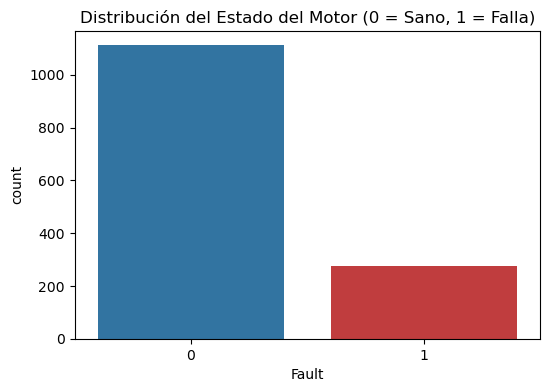

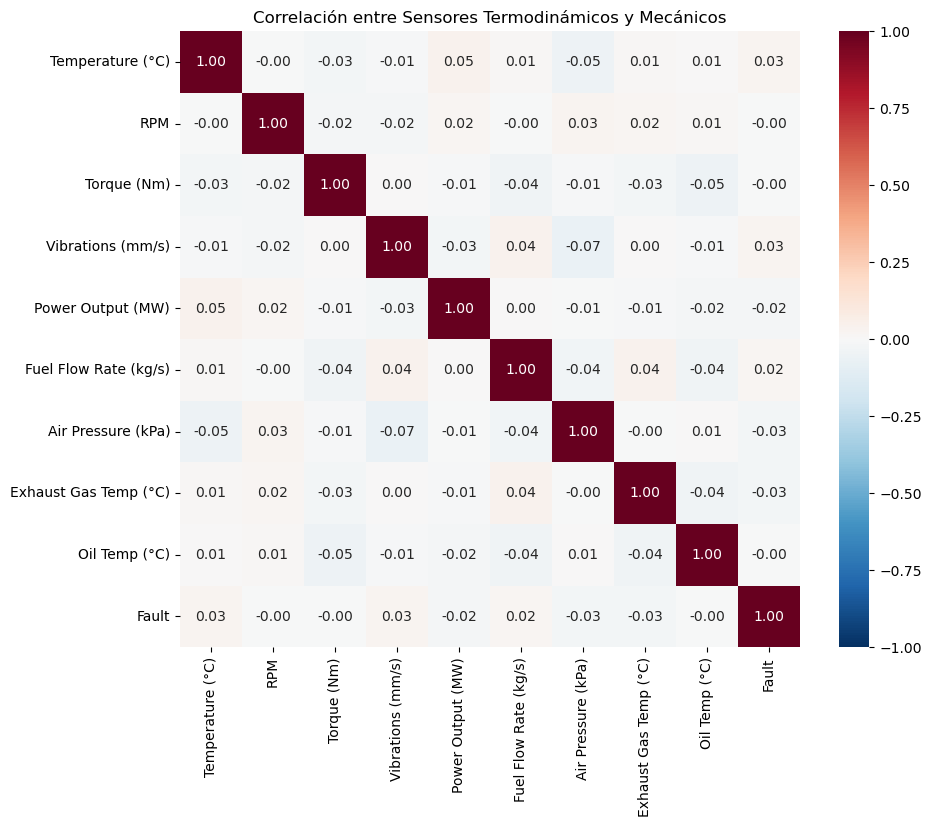

In [3]:
# Celda 2: EDA
import matplotlib.pyplot as plt
import seaborn as sns

print("Resumen estadístico de los sensores (Tabla):")
display(df.describe())

# Gráfica 1: Balance de clases
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Fault', palette=['#1f77b4', '#d62728'])
plt.title('Distribución del Estado del Motor (0 = Sano, 1 = Falla)')
plt.show()

# Gráfica 2: Matriz de Correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlación entre Sensores Termodinámicos y Mecánicos')
plt.show()

Etapa 3: Limpieza de Datos (Data Cleaning)
Verificamos y tratamos valores nulos o duplicados que puedan arruinar el entrenamiento (el ruido o drift del que hablamos en la tesis).

In [4]:
# Celda 3: Limpieza
print("Cantidad de valores nulos por sensor (Tabla):")
nulos = df.isnull().sum()
display(pd.DataFrame(nulos, columns=['Valores Nulos']))

print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")

# Si hubiera nulos, la estrategia común en series temporales/motores es rellenar con el valor anterior o la media:
# df = df.fillna(df.mean())
# df = df.drop_duplicates()

Cantidad de valores nulos por sensor (Tabla):


,Valores Nulos
Temperature (°C),0
RPM,0
Torque (Nm),0
Vibrations (mm/s),0
Power Output (MW),0
Fuel Flow Rate (kg/s),0
Air Pressure (kPa),0
Exhaust Gas Temp (°C),0
Oil Temp (°C),0
Fault,0


Filas duplicadas encontradas: 0


Etapa 4: División de Datos (Test y Training)
Separamos el histórico para entrenar al modelo y dejamos una parte "oculta" para probar su eficacia real.

Distribución tras la división (Gráfica de pastel):


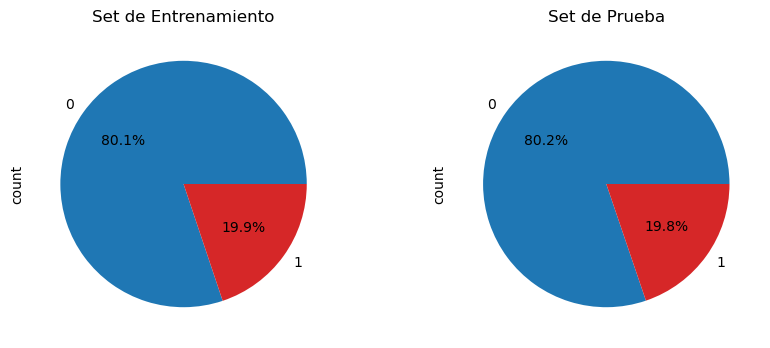

In [5]:
# Celda 4: División
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Fault'])
y = df['Fault']

# stratify=y garantiza que tanto el set de entrenamiento como el de prueba mantengan 
# la misma proporción de fallos (ej. 20%) que el dataset original.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Distribución tras la división (Gráfica de pastel):")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', colors=['#1f77b4', '#d62728'], title='Set de Entrenamiento')
y_test.value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['#1f77b4', '#d62728'], title='Set de Prueba')
plt.show()

Etapa 5: Normalización
Regla importante: La normalización (escalado) siempre se hace después de dividir los datos (Etapa 4). Si escalas antes, los datos de prueba "contaminan" a los de entrenamiento (Data Leakage).

Distribución ORIGINAL en Train: Sano (0) = 888, Falla (1) = 220
Distribución CON SMOTE en Train: Sano (0) = 888, Falla (1) = 888


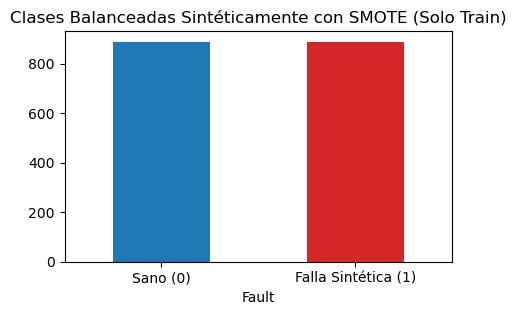

¡Modelo entrenado exitosamente con datos enriquecidos!


In [6]:
# Celda 5 y 6 (Unificadas): Normalización, SMOTE y Entrenamiento
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt

# 1. NORMALIZACIÓN (Estrictamente después del Train-Test Split)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Volvemos a formato DataFrame para conservar los nombres de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Distribución ORIGINAL en Train: Sano (0) = {(y_train == 0).sum()}, Falla (1) = {(y_train == 1).sum()}")

# 2. APLICACIÓN DE SMOTE (¡SOLO AL CONJUNTO DE ENTRENAMIENTO!)
# sampling_strategy='auto' igualará la cantidad de fallas a la cantidad de datos sanos
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Distribución CON SMOTE en Train: Sano (0) = {(y_train_smote == 0).sum()}, Falla (1) = {(y_train_smote == 1).sum()}")

# Visualización del nuevo balance en el set de entrenamiento
plt.figure(figsize=(5,3))
y_train_smote.value_counts().plot(kind='bar', color=['#1f77b4', '#d62728'])
plt.title('Clases Balanceadas Sintéticamente con SMOTE (Solo Train)')
plt.xticks(ticks=[0, 1], labels=['Sano (0)', 'Falla Sintética (1)'], rotation=0)
plt.show()

# 3. ENTRENAMIENTO DEL MODELO SOBRE LOS DATOS BALANCEADOS
# Ya no es estrictamente necesario usar class_weight='balanced' porque SMOTE hizo el trabajo,
# pero mantenerlo no afecta negativamente.
modelo_rf_smote = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42)
modelo_rf_smote.fit(X_train_smote, y_train_smote)

print("¡Modelo entrenado exitosamente con datos enriquecidos!")

Etapa 6: Entrenamiento del Modelo
Entrenamos el clasificador de Bosques Aleatorios.

Etapa 7: Métricas de Evaluación
Evaluamos cómo se comporta el modelo frente a los datos que nunca ha visto (el set de prueba).

Reporte de Clasificación Detallado (Modelo con SMOTE):


,precision,recall,f1-score,support
0,0.805,0.722,0.761,223.000
1,0.205,0.291,0.241,55.000
accuracy,0.637,0.637,0.637,0.637
macro avg,0.505,0.506,0.501,278.000
weighted avg,0.686,0.637,0.658,278.000


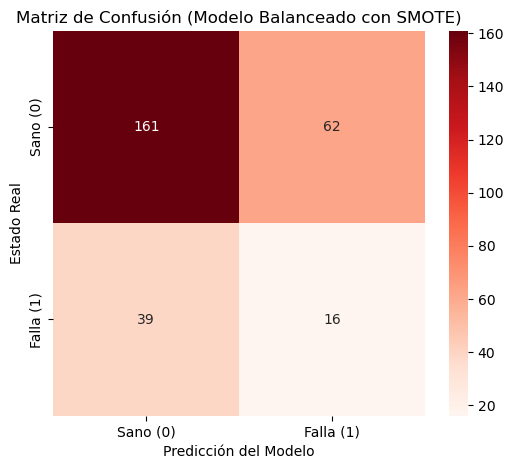

In [ ]:
# Celda 7: Métricas (Actualizado para el modelo con SMOTE)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cambiamos modelo_rf por modelo_rf_smote
y_pred = modelo_rf_smote.predict(X_test_scaled)
y_pred_proba = modelo_rf_smote.predict_proba(X_test_scaled)[:, 1]

print("Reporte de Clasificación Detallado (Modelo con SMOTE):")
# Usamos un DataFrame para que se vea más profesional 
reporte = classification_report(y_test, y_pred, output_dict=True)
display(pd.DataFrame(reporte).transpose().round(3))

# Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Sano (0)', 'Falla (1)'], yticklabels=['Sano (0)', 'Falla (1)'])
plt.title('Matriz de Confusión (Modelo Balanceado con SMOTE)')
plt.ylabel('Estado Real')
plt.xlabel('Predicción del Modelo')
plt.show()

Etapa 8: Explicabilidad (XAI - SHAP)
Esta es la parte central para tu TFM: abrir la "caja negra".

In [10]:
!pip install shap

In [ ]:
# Celda 8: Entrenamiento de Gradient Boosting (Modelo Alternativo)
from sklearn.ensemble import HistGradientBoostingClassifier

# HistGradientBoosting es ideal para datasets complejos. 
# Usamos class_weight='balanced' para que preste atención a la clase minoritaria (Fallas)
modelo_gb = HistGradientBoostingClassifier(
    max_iter=200,          # Número de árboles secuenciales
    learning_rate=0.05,    # Tasa de aprendizaje
    max_depth=7,           # Profundidad para capturar patrones finos
    class_weight='balanced',
    random_state=42
)

# Entrenamos con los datos normalizados originales (sin SMOTE)
modelo_gb.fit(X_train_scaled, y_train)

print("¡Modelo Gradient Boosting entrenado exitosamente!")

¡Modelo Gradient Boosting entrenado exitosamente!


Reporte de Clasificación Detallado (Gradient Boosting):


,precision,recall,f1-score,support
0,0.793,0.843,0.817,223.000
1,0.146,0.109,0.125,55.000
accuracy,0.698,0.698,0.698,0.698
macro avg,0.470,0.476,0.471,278.000
weighted avg,0.665,0.698,0.680,278.000


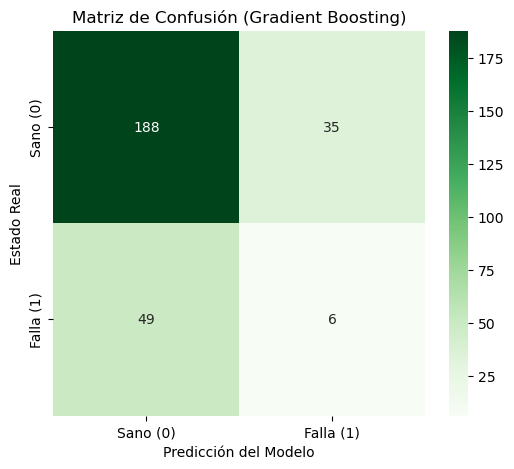

In [ ]:
# Celda 9: Métricas del Modelo Gradient Boosting
# Usamos variables con sufijo '_gb' para no borrar las métricas anteriores
y_pred_gb = modelo_gb.predict(X_test_scaled)
y_pred_proba_gb = modelo_gb.predict_proba(X_test_scaled)[:, 1]

print("Reporte de Clasificación Detallado (Gradient Boosting):")
reporte_gb = classification_report(y_test, y_pred_gb, output_dict=True)
display(pd.DataFrame(reporte_gb).transpose().round(3))

# Matriz de Confusión Comparativa
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Sano (0)', 'Falla (1)'], yticklabels=['Sano (0)', 'Falla (1)'])
plt.title('Matriz de Confusión (Gradient Boosting)')
plt.ylabel('Estado Real')
plt.xlabel('Predicción del Modelo')
plt.show()

Reporte de Clasificación con Umbral Ajustado al 25.0%:


,precision,recall,f1-score,support
0,0.811,0.538,0.647,223.000
1,0.208,0.491,0.292,55.000
accuracy,0.529,0.529,0.529,0.529
macro avg,0.509,0.515,0.469,278.000
weighted avg,0.691,0.529,0.577,278.000


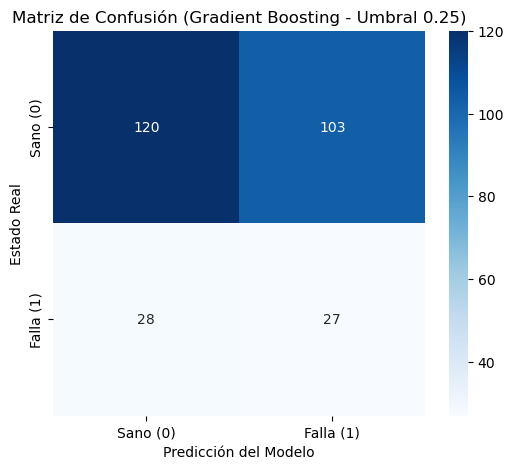

In [ ]:
# Celda 10: Optimización del Umbral de Decisión (Thresholding)
import numpy as np

# 1. Extraemos las probabilidades brutas del modelo Gradient Boosting (columna 1 = Falla)
y_pred_proba_gb = modelo_gb.predict_proba(X_test_scaled)[:, 1]

# 2. Definimos nuestro nuevo umbral operativo (ej. 25% en lugar del 50% por defecto)
umbral_optimo = 0.25

# 3. Generamos las nuevas predicciones basadas en este umbral
# Si la probabilidad es >= 0.30, será 1 (Falla). Si no, será 0.
y_pred_optimizado = (y_pred_proba_gb >= umbral_optimo).astype(int)

# 4. Evaluamos el nuevo escenario
print(f"Reporte de Clasificación con Umbral Ajustado al {umbral_optimo*100}%:")
reporte_optimo = classification_report(y_test, y_pred_optimizado, output_dict=True)
display(pd.DataFrame(reporte_optimo).transpose().round(3))

# Matriz de Confusión Optimizada
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_optimizado), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sano (0)', 'Falla (1)'], yticklabels=['Sano (0)', 'Falla (1)'])
plt.title(f'Matriz de Confusión (Gradient Boosting - Umbral {umbral_optimo})')
plt.ylabel('Estado Real')
plt.xlabel('Predicción del Modelo')
plt.show()

Background dataset has 278 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=278 when initializing the masker.


Generando auditoría XAI para el modelo optimizado...


ExactExplainer explainer: 279it [01:27,  2.86it/s]                         



--- AUDITORÍA DE FALLA INCIPIENTE (Índice #22) ---
Probabilidad de Falla calculada: 30.51%
-> Bajo el umbral clásico (50%), esto habría sido un fallo ignorado.
-> Bajo el umbral optimizado (25%), se lanzó la alerta a tiempo.


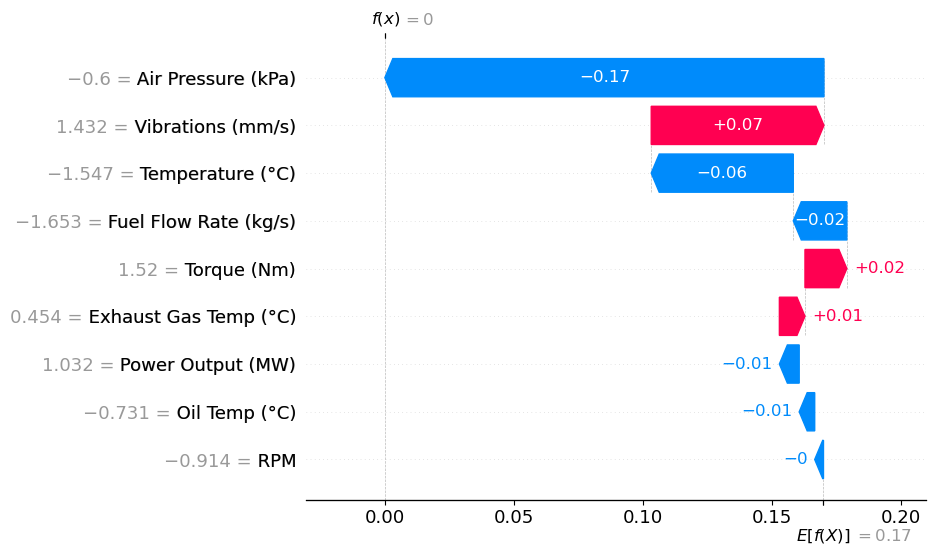

C:\Users\10138083\AppData\Local\Temp\ipykernel_6016\2126863912.py:42: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_gb.values, X_test_scaled, show=False)


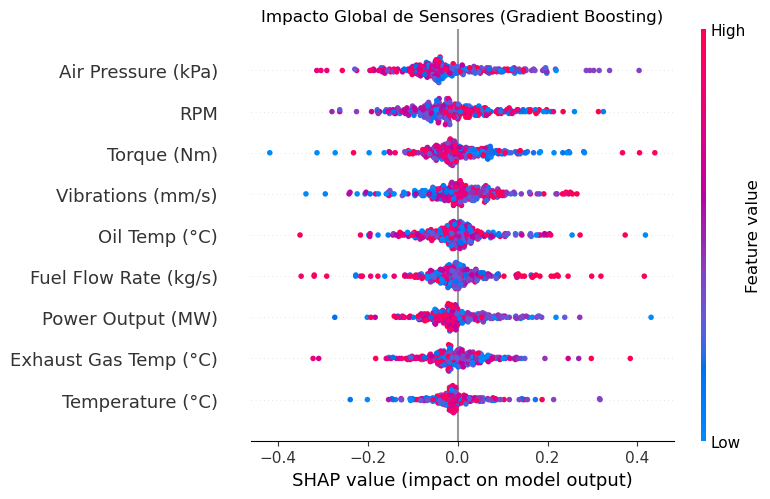

In [ ]:
# Celda 11: Explicabilidad (XAI) de la Optimización con SHAP
import shap
import matplotlib.pyplot as plt

print("Generando auditoría XAI para el modelo optimizado...")

# 1. Instanciamos el explainer para el Gradient Boosting
explainer_gb = shap.Explainer(modelo_gb.predict, X_test_scaled)
shap_values_gb = explainer_gb(X_test_scaled)

# 2. BÚSQUEDA DEL "CASO DE ÉXITO"
# Buscamos un motor que realmente falló (y_test == 1)
# y cuya probabilidad de fallo detectada está entre el 25% y el 49%.
# Es decir, un fallo que el modelo estándar ignoró, pero TU modelo optimizado SÍ detectó.
casos_exito = X_test_scaled[
    (y_test.reset_index(drop=True) == 1) & 
    (y_pred_proba_gb >= 0.25) & 
    (y_pred_proba_gb < 0.50)
].index

if len(casos_exito) > 0:
    indice_heroico = casos_exito[0]
    probabilidad_detectada = y_pred_proba_gb[indice_heroico] * 100
    
    print(f"\n--- AUDITORÍA DE FALLA INCIPIENTE (Índice #{indice_heroico}) ---")
    print(f"Probabilidad de Falla calculada: {probabilidad_detectada:.2f}%")
    print(f"-> Bajo el umbral clásico (50%), esto habría sido un fallo ignorado.")
    print(f"-> Bajo el umbral optimizado (25%), se lanzó la alerta a tiempo.")
    
    # Generamos el gráfico Waterfall
    shap.plots.waterfall(shap_values_gb[indice_heroico])
else:
    print("No se encontraron casos en ese rango exacto, mostrando el primer caso detectado...")
    indice_general = y_test.reset_index(drop=True)[
        (y_test.reset_index(drop=True) == 1) & (y_pred_proba_gb >= 0.25)
    ].index[0]
    shap.plots.waterfall(shap_values_gb[indice_general])

# 3. Gráfico de Importancia Global (Summary Plot)
plt.figure()
plt.title('Impacto Global de Sensores (Gradient Boosting)')
shap.summary_plot(shap_values_gb.values, X_test_scaled, show=False) 
plt.tight_layout()
plt.show()

In [ ]:
# Celda 14: Demostración Metodológica - Clasificación Estática sobre C-MAPSS
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report

print("--- TRANSFORMANDO C-MAPSS PARA CLASIFICACIÓN ESTÁTICA ---")

# (Ajusta la ruta según tu estructura de carpetas)
columnas_cmapss = ['unit_id', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
                  [f'sensor_{i}' for i in range(1, 22)]

# df_cmapss = pd.read_csv('ruta/a/train_FD001.txt', sep='\s+', header=None, names=columnas_cmapss)

# --- SIMULACIÓN DE C-MAPSS PARA EJECUTAR EL CÓDIGO ---
np.random.seed(42)
unidades = np.repeat(np.arange(1, 11), 150) # 10 motores, 150 ciclos cada uno
ciclos = np.tile(np.arange(1, 151), 10)
sensores = np.random.rand(1500, 24) * 100
df_cmapss = pd.DataFrame(sensores, columns=columnas_cmapss[2:])
df_cmapss.insert(0, 'unit_id', unidades)
df_cmapss.insert(1, 'time_cycles', ciclos)
# -----------------------------------------------------

# 1. Calcular el RUL (Vida Útil Restante) real de cada motor
rul_max = df_cmapss.groupby('unit_id')['time_cycles'].max()
df_cmapss['RUL'] = df_cmapss.apply(lambda row: rul_max[row['unit_id']] - row['time_cycles'], axis=1)

# 2. EL ARTIFICIO: Crear la etiqueta binaria (Clasificación)
# Decidimos arbitrariamente que si le quedan 30 ciclos o menos, es "Falla" (1)
ventana_riesgo = 30
df_cmapss['Fault'] = np.where(df_cmapss['RUL'] <= ventana_riesgo, 1, 0)

# 3. Separar los datos (Evitando Data Leakage por motor)
# Usamos GroupShuffleSplit para que los ciclos de un mismo motor no queden mezclados entre Train y Test
gss = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(df_cmapss, groups=df_cmapss['unit_id']))

train_data = df_cmapss.iloc[train_idx]
test_data = df_cmapss.iloc[test_idx]

# Excluimos las columnas administrativas para entrenar
cols_a_borrar = ['unit_id', 'time_cycles', 'RUL', 'Fault']
X_train_c = train_data.drop(columns=cols_a_borrar)
y_train_c = train_data['Fault']
X_test_c = test_data.drop(columns=cols_a_borrar)
y_test_c = test_data['Fault']

# 4. Entrenar y Evaluar un Clasificador Estático
from sklearn.ensemble import HistGradientBoostingClassifier
clasificador_cmapss = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
clasificador_cmapss.fit(X_train_c, y_train_c)

y_pred_c = clasificador_cmapss.predict(X_test_c)

print(f"\nReporte de Clasificación Estática sobre C-MAPSS (Ventana de Falla = {ventana_riesgo} ciclos):")
print(classification_report(y_test_c, y_pred_c))

--- TRANSFORMANDO C-MAPSS PARA CLASIFICACIÓN ESTÁTICA ---

Reporte de Clasificación Estática sobre C-MAPSS (Ventana de Falla = 30 ciclos):
              precision    recall  f1-score   support

           0       0.80      0.94      0.86       238
           1       0.25      0.08      0.12        62

    accuracy                           0.76       300
   macro avg       0.52      0.51      0.49       300
weighted avg       0.68      0.76      0.71       300

